# Tutorial 3: MO diagrams of CH4 and NH3 from symmetry and overlap

**For:** inorganic and computational chemists who want the textbook MO diagram of a molecule, with irrep labels and occupations, from nothing but an XYZ file.
**Time:** about 10 minutes.
**Requirements:** CrystOD >= 0.4.0 (`pip install CrystOD`), which installs pymatgen, matplotlib and pandas. No PySCF is needed: the diagrams here are symmetry-adapted extended Hückel.

What this notebook does:

1. detects the point group of CH4 and NH3 with `crystod.mol.load_molecule` and `get_symmetry`,
2. projects the H 1s SALCs with `crystod.mol.project_salcs` (a1 + t2 for methane, a1 + e for ammonia),
3. builds the MO diagram with `crystod.mol.MODiagram`, reads the levels (energy, irrep, occupation) as a table and draws them with matplotlib,
4. embeds the interactive HTML page that `crystod-mol --diagram` writes, and runs that command.

In [1]:
import crystod

crystod.__version__   # 0.4.0 or later is required

'0.4.0'

In [2]:
import os
import tempfile

workdir = tempfile.mkdtemp(prefix="crystod_tutorial_")
os.chdir(workdir)   # everything this notebook writes lands here, not next to the notebook
workdir

'/var/folders/z9/fy920zrj7jqf_3c45v8_s9400000gn/T/crystod_tutorial_20maq19d'

## The point group

`load_molecule` reads an XYZ file into a pymatgen `Molecule` centered at its center of mass, and `get_symmetry` detects the point group with pymatgen's `PointGroupAnalyzer` (a distance tolerance of 0.3 Å is the pymatgen default) and returns the Schoenflies symbol with the unique symmetry operations as rotation matrices. `SCHOENFLIES_TO_HM` maps the symbol onto the Hermann-Mauguin one the character tables of `crystod-group` are indexed by.

In [3]:
from crystod.examples import example_path
from crystod.mol import SCHOENFLIES_TO_HM, get_symmetry, load_molecule

molecules = {"CH4": example_path("XYZ_CH4.xyz"), "NH3": example_path("XYZ_NH3.xyz")}
for name, path in molecules.items():
    molecule = load_molecule(path)
    schoenflies, operations = get_symmetry(molecule, tolerance=0.3)
    print(f"{name}: {len(molecule)} atoms, point group {schoenflies} "
          f"(Hermann-Mauguin {SCHOENFLIES_TO_HM[schoenflies]}), {len(operations)} symmetry operations")

CH4: 5 atoms, point group Td (Hermann-Mauguin -43m), 24 symmetry operations
NH3: 4 atoms, point group C3v (Hermann-Mauguin 3m), 6 symmetry operations


## H 1s SALCs by projection

The hydrogen 1s orbitals span the site-permutation representation of the H atoms times the (trivial) representation of an s orbital. Applying the projection operator of each irrep, P = (l/h) sum over g of chi(g)* D(g), to that representation gives the symmetry-adapted linear combinations. `project_salcs` needs each operation together with the name of its class in the character table (E, C3, sgd, ...); the two helpers of `crystod.molecular_salc` used below do that class assignment, exactly as `crystod-mol --element H --orbital s` does internally.

In [4]:
import numpy as np

from crystod.group import get_character_table
from crystod.mol import format_salc, get_permutation_matrices, project_salcs
from crystod.molecular_salc import _match_operations, _table_operations_cartesian


def classify_operations(operations, character_table):
    """Name the class of every detected operation and snap it onto the exact table matrix."""
    table_ops, table_classes = _table_operations_cartesian(character_table)
    alignment, matched = _match_operations(operations, table_ops, table_classes)
    snapped = [alignment.T @ table_ops[i] @ alignment for i in matched]
    return snapped, [table_classes[i] for i in matched]


def hydrogen_1s_salcs(name, path, tolerance=0.3):
    molecule = load_molecule(path)
    schoenflies, operations = get_symmetry(molecule, tolerance)
    table = get_character_table(SCHOENFLIES_TO_HM[schoenflies])
    operations, classes = classify_operations(operations, table)
    sites = [i for i, site in enumerate(molecule) if site.specie.symbol == "H"]
    coordinates = np.array([molecule[i].coords for i in sites])
    permutations = get_permutation_matrices(operations, coordinates, tolerance)
    salcs = project_salcs(operations, classes, permutations, 0, table)   # azimuthal number 0: s orbitals
    terms = [f"1s(H{n + 1})" for n in range(len(sites))]
    spanned = " + ".join(irrep + (f" ({len(v)} partners)" if len(v) > 1 else "") for irrep, v in salcs.items())
    print(f"{name} ({schoenflies}): the H 1s orbitals span {spanned}")
    for irrep, vectors in salcs.items():
        for vector in vectors:
            print(f"    {irrep}: {format_salc(vector, terms)}")


for name, path in molecules.items():
    hydrogen_1s_salcs(name, path)

CH4 (Td): the H 1s orbitals span A1 + T2 (3 partners)
    A1: 1s(H1) + 1s(H2) + 1s(H3) + 1s(H4)
    T2: 1s(H1) - 1s(H4)
    T2: 1s(H1) - 2 1s(H2) + 1s(H4)
    T2: 1s(H1) + 1s(H2) - 3 1s(H3) + 1s(H4)
NH3 (C3v): the H 1s orbitals span A1 + E (2 partners)
    A1: 1s(H1) + 1s(H2) + 1s(H3)
    E: 1s(H1) - 1s(H3)
    E: 1s(H1) - 2 1s(H2) + 1s(H3)


In CH4 the four H 1s orbitals give a1 + t2 (the a1 combination matches the C 2s orbital and the t2 triplet the C 2p orbitals); in NH3 they give a1 + e: the N 2px, 2py pair (e) bonds with the e SALC, while the single a1 SALC is shared between N 2s and N 2pz, so one a1 combination, dominated by N 2pz, stays largely nonbonding: the lone pair.

## The MO diagram

`MODiagram` takes the same XYZ file and builds the diagram from symmetry and overlap alone: it symmetrizes the geometry, identifies the central atom and the ligands, projects the ligand SALCs of every valence shell per irrep, evaluates the exact two-center overlaps of single-zeta Slater orbitals, and solves one small secular problem per irrep with the Wolfsberg-Helmholz approximation of extended Hückel theory. Orbitals of different irreps cannot mix, so every MO carries its irrep, and the bonding/antibonding splitting follows the overlap.

The result holds the levels of the four diagram columns (`ligand_ao_levels`, `salc_levels`, `mo_levels`, `center_levels`), each a `Level` with `label`, `irrep`, `energy` in eV, `degeneracy`, `electrons` and `composition` (pairs of a level id and a weight), plus `homo`, `lumo` and `n_electrons`. `print_report()` prints the full command-line report and `write_html()` writes the interactive page.

In [5]:
import pandas as pd
from crystod.mol import MODiagram

diagram = MODiagram(molecules["CH4"])
print(diagram.formula, diagram.schoenflies, "-", diagram.n_electrons, "valence electrons;",
      "HOMO", diagram.homo.label, f"({diagram.homo.energy:.2f} eV),",
      "LUMO", diagram.lumo.label, f"({diagram.lumo.energy:.2f} eV)")

CH4 Td - 8 valence electrons; HOMO 1t2 (-15.52 eV), LUMO 2t2 (4.74 eV)


In [6]:
def level_table(diagram):
    """The MO levels highest first, as in the crystod-mol report."""
    names = {level.level_id: f"SALC {level.label}" for level in diagram.salc_levels}
    names |= {level.level_id: f"{diagram.symbols[diagram.center]} {level.label.split()[0]}"
              for level in diagram.center_levels}
    rows = []
    for level in reversed(diagram.mo_levels):
        composition = ", ".join(f"{100 * w:.0f}% {names[i]}"
                                for i, w in sorted(level.composition, key=lambda kv: -kv[1]) if w > 0.005)
        rows.append({"MO": level.label, "irrep": level.irrep, "E (eV)": round(level.energy, 2),
                     "degeneracy": level.degeneracy, "electrons": level.electrons,
                     "character": level.bond_character, "composition": composition})
    return pd.DataFrame(rows)


level_table(diagram)

,MO,irrep,E (eV),degeneracy,electrons,character,composition
0,3a1,A1,33.44,1,0,antibonding,"62% SALC a1, 38% C 2s"
1,2t2,T2,4.74,3,0,antibonding,"52% C 2p, 48% SALC t2"
2,1t2,T2,-15.52,3,6,bonding,"52% SALC t2, 48% C 2p"
3,2a1,A1,-24.56,1,2,bonding,"62% C 2s, 38% SALC a1"


The MO numbering counts the core shells, as in photoelectron spectroscopy: 1a1 is the C 1s core (not shown), so methane is (2a1)^2 (1t2)^6 with the t2 triplet as HOMO. The energies are semi-quantitative, as extended Hückel energies always are; read them for orderings and trends.

## A level diagram with matplotlib

Three columns: the ligand SALCs on the left, the molecular orbitals in the middle, the central-atom orbitals on the right. Degenerate levels are drawn as side-by-side segments, arrows mark the electrons, and the dashed correlation lines carry the composition (the heavier, the larger the weight). NH3 is built the same way and drawn next to CH4.

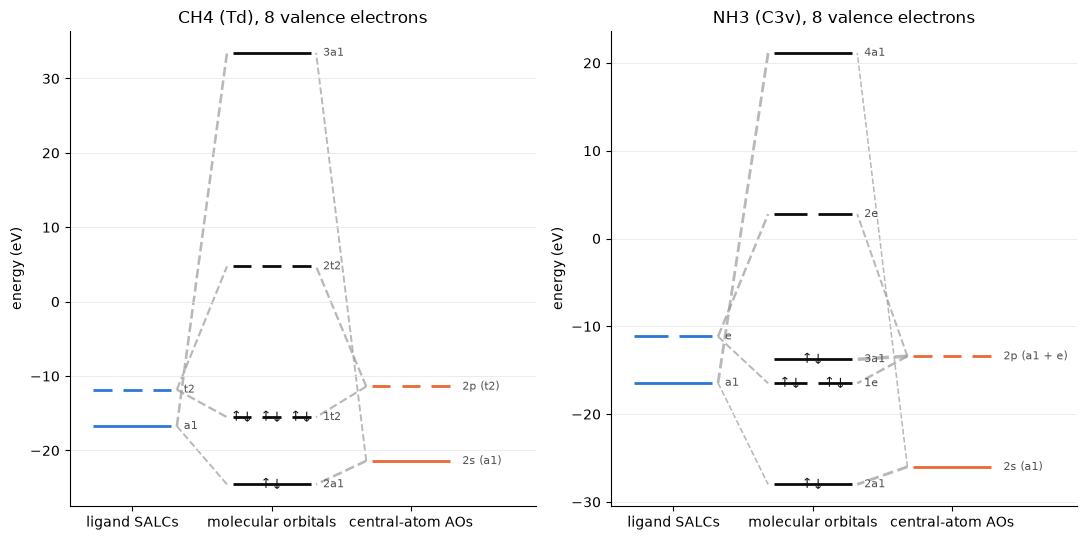

In [7]:
%matplotlib inline
import matplotlib.pyplot as plt

COLUMNS = {"salc": (0.0, "#2a78d6", "ligand SALCs"),
           "mo": (1.0, "#0b0b0b", "molecular orbitals"),
           "center-ao": (2.0, "#eb6834", "central-atom AOs")}


def draw_level_diagram(diagram, ax, half=0.32):
    edges = {}   # level id -> (left x, right x, energy)
    for column, levels in (("salc", diagram.salc_levels), ("mo", diagram.mo_levels),
                           ("center-ao", diagram.center_levels)):
        x0, color, _ = COLUMNS[column]
        for level in levels:
            n = level.degeneracy
            slot = 2 * half / n
            for k in range(n):
                xa, xb = x0 - half + k * slot + 0.04, x0 - half + (k + 1) * slot - 0.04
                ax.hlines(level.energy, xa, xb, color=color, lw=2)
                electrons = level.electrons // n
                if electrons:
                    ax.text((xa + xb) / 2, level.energy, "\u2191\u2193" if electrons == 2 else "\u2191",
                            ha="center", va="center", fontsize=9, color=color)
            ax.text(x0 + half + 0.05, level.energy, level.label, va="center", fontsize=8, color="#52514e")
            edges[level.level_id] = (x0 - half, x0 + half, level.energy)
    for level in diagram.mo_levels:
        mo_left, mo_right, _ = edges[level.level_id]
        for other, weight in level.composition:
            if weight < 0.05 or other not in edges:
                continue
            xa, xb, energy = edges[other]
            x_pair = (xb, mo_left) if xb <= COLUMNS["mo"][0] else (xa, mo_right)
            ax.plot(x_pair, [energy, level.energy], color="#9a9a9a", lw=0.6 + 2 * weight, ls="--",
                    alpha=0.7, zorder=0)
    ax.set_xticks([v[0] for v in COLUMNS.values()], [v[2] for v in COLUMNS.values()])
    ax.set_xlim(-0.45, 2.9)
    ax.set_ylabel("energy (eV)")
    ax.grid(axis="y", color="#e5e5e5", lw=0.5)
    ax.set_title(f"{diagram.formula} ({diagram.schoenflies}), {diagram.n_electrons} valence electrons")
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)


diagrams = {"CH4": diagram, "NH3": MODiagram(molecules["NH3"])}
fig, axes = plt.subplots(1, 2, figsize=(11, 5.5), dpi=100)
for ax, (name, d) in zip(axes, diagrams.items()):
    draw_level_diagram(d, ax)
plt.tight_layout()
plt.show()

In [8]:
level_table(diagrams["NH3"])

,MO,irrep,E (eV),degeneracy,electrons,character,composition
0,4a1,A1,21.14,1,0,antibonding,"70% SALC a1, 25% N 2s, 5% N 2p"
1,2e,E,2.78,2,0,antibonding,"59% SALC e, 41% N 2p"
2,3a1,A1,-13.75,1,2,bonding,"95% N 2p, 4% SALC a1, 1% N 2s"
3,1e,E,-16.49,2,4,bonding,"59% N 2p, 41% SALC e"
4,2a1,A1,-28.00,1,2,bonding,"73% N 2s, 27% SALC a1"


NH3 fills (2a1)^2 (1e)^4 (3a1)^2: the 3a1 HOMO is 95% N 2p with almost no ligand character, the nonbonding lone pair, while the 1e pair carries the N-H bonds together with 2a1.

## The interactive HTML page

`write_html` writes the page that `crystod-mol --diagram` produces: four columns (isolated ligand AOs | ligand SALCs | MOs | central AOs) with correlation lines and electron filling, and a drag-rotatable orbital sketch of every level built from its actual eigenvector (hover or click a level; Ctrl/Cmd + scroll zooms the energy window). The file is self-contained, so it is embedded here as an inline frame. GitHub's notebook viewer drops frames; open the notebook on nbviewer or run it locally to see it.

In [9]:
import html

from IPython.display import HTML

diagram.write_html("MolOD_XYZ_CH4.html")   # the file crystod-mol --diagram --xyz XYZ_CH4.xyz writes
page = open("MolOD_XYZ_CH4.html", encoding="utf-8").read()
print(f"MolOD_XYZ_CH4.html: {len(page) / 1024:.0f} kB, no external resources")
frame = (f'<iframe srcdoc="{html.escape(page)}" width="100%" height="640" '
         'style="border:1px solid #ccc; border-radius:6px; background:#fff"></iframe>')
HTML(f"<div>{frame}</div>")

MolOD_XYZ_CH4.html: 30 kB, no external resources


## The command line: `crystod-mol --diagram`

`crystod-mol --diagram --xyz XYZ_NH3.xyz` prints the report (AO parameters, ligand SALCs, SALC | central-AO overlap integrals, the MO level table and the electron filling) and writes `MolOD_XYZ_NH3.html`; `crystod-mol --example NH3` copies the bundled XYZ file into the current directory and runs that command. Here the file is copied with `crystod.examples.copy_example_files` and the command runs through `subprocess` in the temporary directory.

In [10]:
import subprocess
import sys

from crystod.examples import copy_example_files, get_example

copy_example_files(get_example("crystod-mol", "NH3"), workdir)   # XYZ_NH3.xyz
command = [sys.executable, "-m", "crystod.cli.mol", "--diagram", "--xyz", "XYZ_NH3.xyz"]   # == crystod-mol
run = subprocess.run(command, cwd=workdir, capture_output=True, text=True, check=True)
print(run.stdout)
print(sorted(os.listdir(workdir)))


* Molecule *
XYZ_NH3.xyz (NH3, 4 atoms)

* Point group *
C3v (Hermann-Mauguin: 3m)

* Fragments *
central atom: N; ligands: 3 H

* Valence Atomic Orbital (AO) parameters (single-zeta STO, extended Hueckel) *
N 2s:  zeta = 1.950 / bohr,  H_ii = -26.0 eV
N 2p:  zeta = 1.950 / bohr,  H_ii = -13.4 eV
H 1s:  zeta = 1.300 / bohr,  H_ii = -13.6 eV

* Ligand SALCs (standard point-group axes) *
-- 3H 1s --
A1: [1s(H1) + 1s(H2) + 1s(H3)]
E: [1s(H1) - 1s(H3), 1s(H1) - 2 1s(H2) + 1s(H3)]

* Ligand SALC | central AO overlap integrals *
  A1:  < a1 (E =  -16.44 eV) | N 2s >  S = 0.7205
  A1:  < a1 (E =  -16.44 eV) | N 2p >  S = 0.2387
   E:  < e (E =  -11.16 eV) | N 2p >  S = 0.5687

* Molecular orbitals (Wolfsberg-Helmholz, K = 1.75) *
    MO    E (eV)  occ  composition
   4a1     21.14    0  70% SALC a1, 25% N 2s, 5% N 2p
 2e x2      2.78    0  59% SALC e, 41% N 2p
   3a1    -13.75    2  95% N 2p, 4% SALC a1, 1% N 2s
 1e x2    -16.49    4  59% N 2p, 41% SALC e
   2a1    -28.00    2  73% N 2s, 27%

## Where next

- [33. Molecular-orbital diagrams](https://mochizuki-tus.github.io/CrystOD/crystod-mol.html#molecular-orbital-diagrams-diagram) in the manual: `--center` for the central atom, two-fragment diagrams with `--ao-left`/`--ao-right` (H6 + C6 for benzene), and the quantitative `--pyscf` diagrams from three PySCF calculations (`pip install 'CrystOD[quantum]'`).
- [32. Molecular point groups and SALCs](https://mochizuki-tus.github.io/CrystOD/crystod-mol.html#molecular-point-groups-and-salcs): the SALC analysis of any element and shell (`--element N --orbital p`), and `--visualize` for a 3D viewer of the SALCs.
- [How the orbital diagrams are computed](https://mochizuki-tus.github.io/CrystOD/theory-orbital-diagrams.html): the extended-Hückel construction step by step, the overlap quadrature and the references.
- The same construction for a crystal, one page per k point: [3. Crystal-orbital diagrams](https://mochizuki-tus.github.io/CrystOD/crystod.html#crystal-orbital-diagrams) (`crystod --diagram -c POSCAR --co-left Sc --co-right F3`).